### Helmholtz free energy

$$A = U-TS$$

For a binary mixture, the free energy per atom is

$$A = \alpha X_A X_B + k_B T \big[ X_A \ln X_A + X_B \ln X_B\big],$$

where $U= \alpha X_A X_B$ is the bonding energy and $S =-k_B T \big[ X_A \ln X_A + X_B \ln X_B\big]$ is the configurational entropy per atomic site.

Normalized with $k_B T$, A becomes

$$A' = \frac{\alpha}{k_B T} X_A (1-X_A) + \big[ X_A \ln X_A + \big(1-X_A\big) \ln \big(1-X_A\big) \big]= \alpha'X_A (1-X_A) + \big[X_A \ln X_A + \big(1-X_A\big) \ln \big(1-X_A\big)\big]. $$

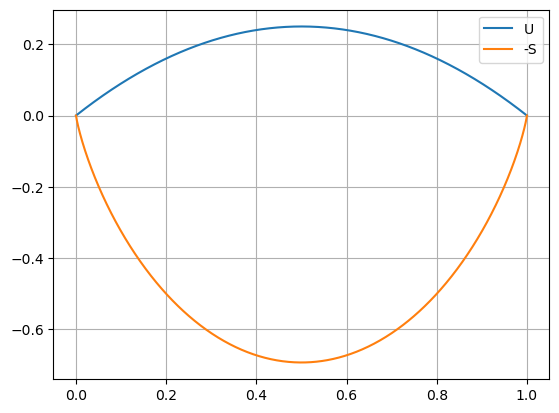

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(1.0e-6, 1-1.0e-6,1001)


U = X*(1-X)
S = -(X*np.log(X) + (1-X)*np.log(1-X))

plt.plot(X, U, label = 'U')
plt.plot(X, -S, label = '-S')
plt.legend()
plt.grid(True) 


Assuming the bonding energy is not sensitive to temperature, since $\alpha' = \frac{\alpha}{k_BT}$, its value decreases as $T$ increases. 

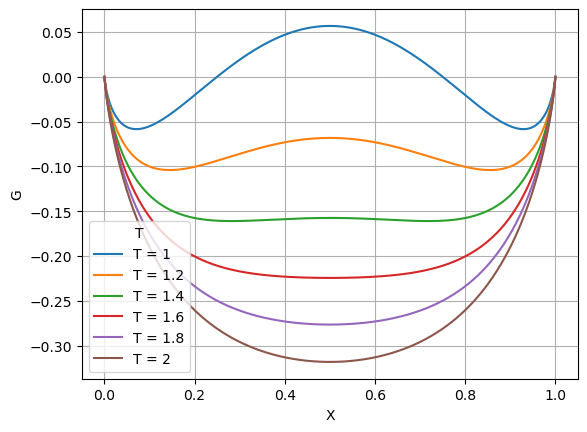

In [3]:
ak = 3

T = np.linspace(1,2,6)
X = np.linspace(1.0e-6, 1-1.0e-6,1001)


for Tk in T:
    G = (ak/Tk)*X*(1-X) + X*np.log(X) + (1-X)*np.log(1-X)
    plt.plot(X, G, label=fr"T = {Tk:.3g}")   # format how you like: .2f, .3g, etc.

plt.grid(True)
plt.legend(title="T", loc="best")  # or loc="upper right", ncol=2, etc.
plt.xlabel("X"); plt.ylabel("G")
plt.show()

---
The energy minima of the double-well free energy function is the binodal points. Varying temperatures, the binodal points connecting together as the phase boundary.

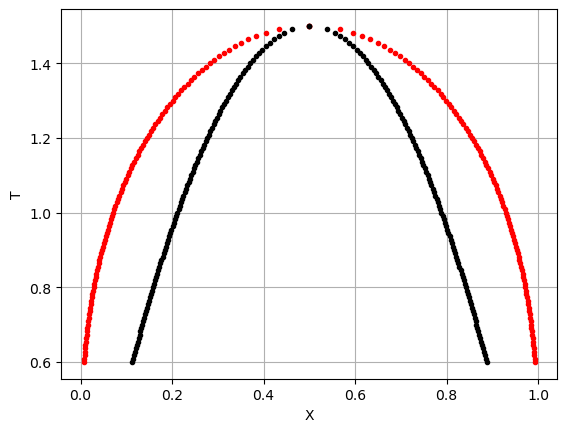

In [7]:
import numpy as np
from math import log
from scipy.optimize import brentq


def dG(x, chi):
    return chi*(1 - 2*x) + log(x) - log(1 - x)

def minima(a, T, eps=1e-12):
    chi = a/T
    if chi < 2:                     # single minimum at 0.5
        return [0.5]
    # two minima: bracket roots left/right of 0.5
    f = lambda x: dG(x, chi)
    left  = brentq(f, eps, 0.5 - 1e-8)
    right = brentq(f, 0.5 + 1e-8, 1 - eps)
    return [left, right]

def spinodal_points(a, T):
    disc = 1.0 - 2.0*T/a
    if disc < 0:
        return []  # no spinodal
    r = np.sqrt(max(0.0, disc))
    return [(1 - r)/2, (1 + r)/2]  # X_s^-, X_s^+


# example
# a, T = 3.0, 1.0          # chi = 3 > 2 → two minima
# print(minima(a, T))      # e.g. [x*, 1-x*]

ak = 3
T = np.linspace(0.6,1.5,100)
T
for Tk in T:
    bnd = minima(ak, Tk, eps=1e-12)
    spn = spinodal_points(ak, Tk)

    for p in range(np.size(bnd)):
        if np.size(bnd) > 1:
            plt.plot(bnd[p],Tk,'.',c='r')
            plt.plot(spn[p],Tk,'.',c='k')

plt.xlabel("X")
plt.ylabel("T")
plt.grid(True)